<a href="https://colab.research.google.com/github/hamshini1413/NLP/blob/main/NLP5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install wordcloud

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import CountVectorizer

from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [6]:
!pip install kaggle
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d crowdflower/twitter-airline-sentiment
!unzip twitter-airline-sentiment.zip
import pandas as pd

df = pd.read_csv("Tweets.csv")

df.head()

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment
License(s): CC-BY-NC-SA-4.0
100% 2.55M/2.55M [00:00<00:00, 4.10MB/s]

Archive:  twitter-airline-sentiment.zip
  inflating: Tweets.csv              
  inflating: database.sqlite         


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [8]:
df.columns

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')

In [9]:
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [13]:
df = df[['text']]

df.head()

,text
0,@VirginAmerica What @dhepburn said.
1,@VirginAmerica plus you've added commercials t...
2,@VirginAmerica I didn't today... Must mean I n...
3,@VirginAmerica it's really aggressive to blast...
4,@VirginAmerica and it's a really big bad thing...


In [16]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z ]", "", text)

    words = word_tokenize(text)

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["Cleaned"] = df["text"].apply(clean_text)

df.head()

,text,Cleaned
0,@VirginAmerica What @dhepburn said.,virginamerica dhepburn said
1,@VirginAmerica plus you've added commercials t...,virginamerica plus youve added commercials exp...
2,@VirginAmerica I didn't today... Must mean I n...,virginamerica didnt today must mean need take ...
3,@VirginAmerica it's really aggressive to blast...,virginamerica really aggressive blast obnoxiou...
4,@VirginAmerica and it's a really big bad thing...,virginamerica really big bad thing


In [17]:
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):

    score = sia.polarity_scores(text)["compound"]

    if score >= 0.05:
        return "Positive"

    elif score <= -0.05:
        return "Negative"

    else:
        return "Neutral"

df["Sentiment"] = df["Cleaned"].apply(get_sentiment)

df.head()

,text,Cleaned,Sentiment
0,@VirginAmerica What @dhepburn said.,virginamerica dhepburn said,Neutral
1,@VirginAmerica plus you've added commercials t...,virginamerica plus youve added commercials exp...,Neutral
2,@VirginAmerica I didn't today... Must mean I n...,virginamerica didnt today must mean need take ...,Neutral
3,@VirginAmerica it's really aggressive to blast...,virginamerica really aggressive blast obnoxiou...,Negative
4,@VirginAmerica and it's a really big bad thing...,virginamerica really big bad thing,Negative


In [18]:
sentiment_counts = df["Sentiment"].value_counts()

print(sentiment_counts)

Sentiment
Positive    7915
Negative    3766
Neutral     2959
Name: count, dtype: int64


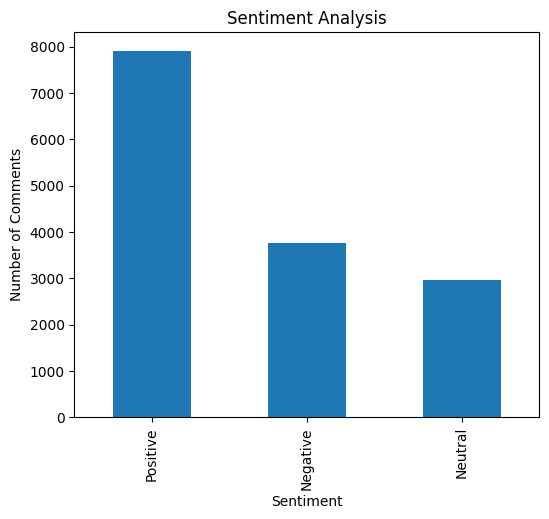

In [19]:
plt.figure(figsize=(6,5))

sentiment_counts.plot(kind='bar')

plt.title("Sentiment Analysis")

plt.xlabel("Sentiment")

plt.ylabel("Number of Comments")

plt.show()

In [20]:
vectorizer = CountVectorizer(stop_words='english')

X = vectorizer.fit_transform(df["Cleaned"])

word_counts = np.asarray(X.sum(axis=0)).flatten()

words = vectorizer.get_feature_names_out()

frequency = pd.DataFrame({
    "Word": words,
    "Count": word_counts
})

frequency = frequency.sort_values(by="Count", ascending=False)

frequency.head(20)

,Word,Count
12099,united,4143
4296,flight,3893
12243,usairways,3051
443,americanair,2957
10691,southwestair,2453
6100,jetblue,2359
11426,thanks,1071
1690,cancelled,1056
10228,service,953
5234,help,855


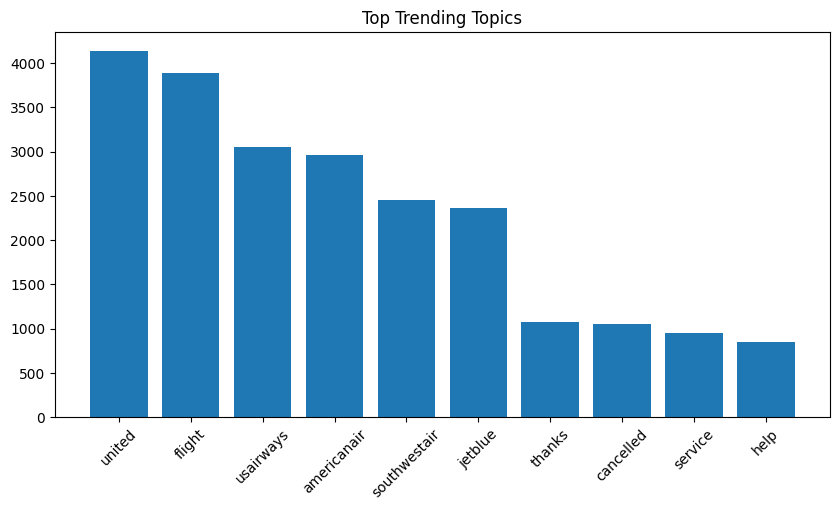

In [21]:
top = frequency.head(10)

plt.figure(figsize=(10,5))

plt.bar(top["Word"], top["Count"])

plt.xticks(rotation=45)

plt.title("Top Trending Topics")

plt.show()

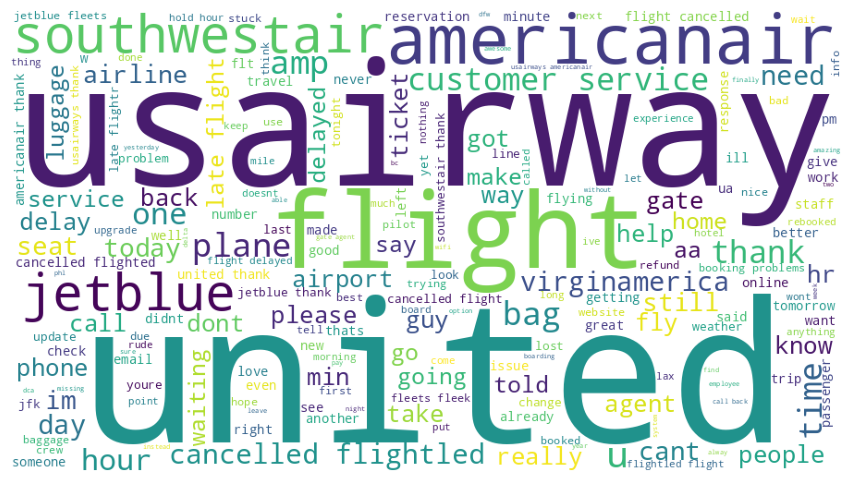

In [22]:
text = " ".join(df["Cleaned"])

wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

In [23]:
df.to_csv("Social_Media_Analysis_Output.csv", index=False)

print("File saved successfully.")

File saved successfully.


In [24]:
df.head(20)

,text,Cleaned,Sentiment
0,@VirginAmerica What @dhepburn said.,virginamerica dhepburn said,Neutral
1,@VirginAmerica plus you've added commercials t...,virginamerica plus youve added commercials exp...,Neutral
2,@VirginAmerica I didn't today... Must mean I n...,virginamerica didnt today must mean need take ...,Neutral
3,@VirginAmerica it's really aggressive to blast...,virginamerica really aggressive blast obnoxiou...,Negative
4,@VirginAmerica and it's a really big bad thing...,virginamerica really big bad thing,Negative
5,@VirginAmerica seriously would pay $30 a fligh...,virginamerica seriously would pay flight seats...,Positive
6,"@VirginAmerica yes, nearly every time I fly VX...",virginamerica yes nearly every time fly vx ear...,Positive
7,@VirginAmerica Really missed a prime opportuni...,virginamerica really missed prime opportunity ...,Positive
8,"@virginamerica Well, I didn't…but NOW I DO! :-D",virginamerica well didntbut,Positive
9,"@VirginAmerica it was amazing, and arrived an ...",virginamerica amazing arrived hour early youre...,Positive
